# コレスポンデンス分析
- 略してコレポン
  - 数量化III類（Quantification Theory III）、対応分析（CA: Correspondence Analysis）、多重対応分析（MCA: Multiple Correspondence Analysis）、双対尺度法（Dual Scaling）など、呼び方や近縁手法が複数存在し、数理的には非常に近い関係にある
  - ここでは「コレポン」表現をメインに据えている。実際にはCAだったりMCAだったりするが数理的背景は非常に近いため細かい区別は気にしない

- point
  - 観測データを単純化することで、データの背後にある潜在的な要素を解釈しやすくする
  - 質的データ（カテゴリデータ）の関係構造を探索するのに適している
  - 主成分分析（Principal Component Analysis）と数理的に近い構造を持つ
  - PCA同様にデータを縮約して、2次元プロットなどで可視化できる
  - 統計的厳密性よりは、結果解釈のしやすさや仮説探索的手法として喜ばれやすい（コレポンに限らない）
  - 大雑把な傾向把握にとどめるのが望ましい（細かいことを気にしないことこそコレポンらしさかも）

- Rの場合
  1. インストールして `library(ca)` 
  1. 読み込んで実行して `ca(table.T)`
  1. 可視化 `plot(ca(table.T))`

- Pythonの場合
  - ここではmcaライブラリを使用 `python -m pip install mca`
  - 単機能でシンプルではあるが、新規に始めるならprinceライブラリの方がいろんなことに使いやすいかも

## コレポンとPCA
- コレポンの特徴
  - カテゴリデータや頻度データの関連構造を少数の軸で表現する手法。期待頻度からのズレ（カイ二乗統計量）が大きい方向を探す。
  - カイ二乗距離に基づく幾何を前提としている。行・列の周辺度数で基準化した行列を特異値分解する。
  - 行と列を双対的に扱い、同一空間上に同時布置できる。
- PCA（主成分分析）の特徴 
  - 数値データの分散構造を少数の軸で表現する手法。データのばらつき（分散）が最大になる方向を探す。
  - ユークリッド距離に基づく幾何を前提としている。共分散行列または相関行列を固有値分解する。
  - 行（サンプル）は主成分スコア、列（変数、特徴量）は負荷量として表現される。
- コレポンとPCAの共通点
  - 多変量データの構造を少数の軸で要約・可視化する次元圧縮手法（データの背後にある構造を捉えるためのもの）
  - データ中の「似たパターン」や「関係構造」を低次元空間へ埋め込む（低次元に圧縮して、似た回答傾向を可視化する）
  - 元データを座標空間へ変換し、近い点ほど似た性質を持つと解釈できる
  - 軸ごとの構造を使って、クラスタ傾向や潜在的な特徴を読み解ける
- コレポンとPCAの相違点
  - コレポンとPCAは、少なくとも数理的な骨格は同じ
  - 軸の解釈に対する考え方の違い、解析結果の安定性など運用上は多くの相違点が存在する（PCAにおける軸は量的な増減方向として解釈しやすい。コレポンにおける軸はカテゴリの対立軸として表れやすい）
  - だがコレポンは適用範囲が広い。理論的前提から多少外れていても、大まかな構造把握用途では有用な場合が多い。特に順序尺度のアンケートデータなどでは、PCA的に見るかコレポン的に見るかの境界が曖昧になることも多い


## コレポンの注意点
- 仮説探索や構造把握に向いた手法であり、推定や検定のような厳密性を主目的とする分析とは少し性格が異なる
- 適用範囲が広い（深く捉えなくともなんでも実行しやすい）とはいえ、本来持っていた情報を相当捨てていることは気に留めておく
- 変数間で尺度の意味が大きく異なるデータには向かない（例えば年収と身長と気温を同列の変数として扱うのは不適切）
- PCA同様に異常値や希少カテゴリは空間構造をゆがめやすい

## コレポンの実情
- 特にマーケティング分野におけるアンケート調査データにおいて重宝されやすい
- 「結果の見た目がわかりやすい」「直感的に理解しやすい」「解釈やストーリーを考察しやすいので話が弾む」などが主な理由として考えられる
- 他に「クロス数表があればできちゃう」「たいていの設問形式に対応できちゃう（ように感じやすい）」「簡単な操作で簡単なアウトプットが得られちゃう」もありそう
- 理論的美しさよりも、実行しやすさや適用範囲の広さ、データの背後構造の見えやすさが魅力と言える

## コレポンの守備範囲
- 理論的には、行・列ともにカテゴリデータの頻度表（人数、出現数などのcountデータ）を対象としている
  - 例えば、行に「カフェのメニュー」、列に「性年代区分」を置いたデータセット（各メニューを好きと回答した人数の性年代別集計値）でおこなうのが王道
  - だがクロス数表を読み慣れている場合はコレポンやる意義を感じにくいかも
  - 性別や年代による違いは想像がしやすいため（ある程度わかってる顕在的要素をなぞってるだけに見えるぶんコレポンの利点が活かされにくい）
- コレポンをよく使う場面
  - 例えば、行に「カフェのメニュー」、列に「イメージワード」を置いたデータセット（各メニューの印象にあてはまるワードを選択した人数のワード別集計値）
  - イメージが似てるメニューはどれとどれなのか、逆に似ていないのはどれかといった解釈がしやすい（クロス数表からは読み解きにくい）
  - コレポンの理論的枠組みからはやや外れるが、コレポンやる意義を感じさせやすい
- 他に、
  - 行に「回答者」、列に「イメージワード」を置いたデータセット（回答者各自がカフェの印象にあてはまるワードに5段階評価したローデータ）
  - これも理論的枠組みからは外れる（PCAっぽいともいえる）が、ある人がどんなワードを重視してるか、似た者同士は誰かといった解釈がしやすい

- 比率表（回答者数全体に占める割合、%データ）のデータセット
  - コレポン自体は実行できるし、頻度表よりも入手しやすい場面もあるなどこちらでおこなう人が多数派かもしれない
  - これまた理論的枠組みからは外れるが、単純化するという性質からさほど弊害が表れにくい（頻度表での実行結果と大差ないなど）
  - 同様理由で、表の縦%や横%が100を超える場合（複数回答形式設問）でもおこなわれているだろう
  
## コレポン結論
- 理論を超えて使いやすいが、わかりやすさに引きづられない
- 簡単に得られる情報と引き換えに、捨てている情報も多いことを忘れない

In [26]:
# import
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
# import seaborn as sns
import mca

# create datetime
print("Created(JST)", pd.Timestamp.now(tz="Asia/Tokyo").strftime("%Y-%m-%d %H:%M:%S"))

# version
import sys;print("Python", sys.version.split()[0])
import platform;print("OS", platform.platform())
print("is_google_colab:", "google.colab" in sys.modules)
from importlib.metadata import version
packages = [
"pandas",
"numpy",
"matplotlib",
# "seaborn",
"mca"
]
for pkg in packages:
    try:
        print(pkg, version(pkg))
    except Exception as e:
        print(pkg, "not installed")

Created(JST) 2026-05-15 18:58:27
Python 3.11.15
OS macOS-26.5-arm64-arm-64bit
is_google_colab: False
pandas 2.2.0
numpy 1.26.4
matplotlib 3.10.9
mca 1.0.4


# ここでのコレポン実行例
- 【背景】あるカフェのお客様アンケート結果をコレポンしてみる
  - お店のメニューやカフェ利用に関して聴取
  - コレポン本来の理論に忠実なデータセットも、実務的なデータセットもあり
  - いずれもサンプルデータ（ダミーデータ）

1. メニュー × イメージワード
   - 実務においてありがちなコレポンの使い方
   - お店のメニュー（8品）それぞれに対して、印象にあてはまるイメージワード（8項目）をMA（複数回答可能形式）で聴取
   - 行（メニュー）、列（イメージワード）のクロス数表（選択した人数の頻度表）
   - MA選択率よりはイメージワード各5段階評価のTOP2人数の方がコレポン理論には近い。とはいえ回答者負荷の高い設問形式を推奨したくない意図
1. メニュー × 性年代区分
   - コレポンの理論的枠組みに沿った使い方
   - お店のメニュー（8品）それぞれに対して、今後（も）注文したいかを5段階評価（あてはまる〜あてはまらない）で聴取
   - 行（メニュー）、列（性年代区分）のクロス数表（5段階評価のうちTOP2を選択した人数の頻度表）
   - コレポン王道路線ではあるものの、ダミーデータながらも結果は面白みに欠ける
1. 回答者 × 5段階評価
   - PCAっぽいデータセットでのコレポンの使い方
   - カフェ利用の総合満足度に関連しそうなイメージワード（10項目）それぞれに対して5段階評価（満足〜不満）で聴取
   - 行（回答者）、列（イメージワード）のローデータ（5段階の評定項目ママ）
   - 初来店のお客様10人を類型化することで、今後戦略の参考にしたい意図

# 1. メニュー × イメージワード

In [27]:
# サンプルのdataframeを生成する

# メニュー（行）
menus = ['Coffee', 'Tea', 'Latte', 'Espresso', 'Cake', 'Sandwich', 'Cookie', 'Toast']

# イメージワード（列）
words = ['香り高い', 'コスパが良い', '見た目が映える', '濃厚な味わい', 
         'ボリューム満点', '手軽に食べれる', '贅沢な気分', '健康的なイメージ']

# プロットがある程度バラつくように、『Tea』『Cookie』『手軽に食べれる』が中心近辺にくるように平均的な値に寄せている
data = [
    [50, 25,  5, 15,  5, 30, 10,  5], # Coffee
    [25, 20, 15, 10, 10, 35, 15, 15], # Tea
    [10, 10, 45, 35, 10, 20, 30,  5], # Latte
    [40, 10, 10, 55,  5, 15, 25,  5], # Espresso
    [10, 10, 50, 30, 10, 15, 45,  5], # Cake
    [ 5, 25, 10,  5, 50, 40,  5, 30], # Sandwich
    [20, 20, 18, 15, 15, 30, 15, 12], # Cookie
    [10, 40,  5,  5, 35, 40,  5, 20], # Toast
]

df = pd.DataFrame(data, index=menus, columns=words)

In [28]:
print(df.head())
# print(df.tail())
# print(df.info())

          香り高い  コスパが良い  見た目が映える  濃厚な味わい  ボリューム満点  手軽に食べれる  贅沢な気分  健康的なイメージ
Coffee      50      25        5      15        5       30     10         5
Tea         25      20       15      10       10       35     15        15
Latte       10      10       45      35       10       20     30         5
Espresso    40      10       10      55        5       15     25         5
Cake        10      10       50      30       10       15     45         5


In [29]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, Coffee to Toast
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   香り高い      8 non-null      int64
 1   コスパが良い    8 non-null      int64
 2   見た目が映える   8 non-null      int64
 3   濃厚な味わい    8 non-null      int64
 4   ボリューム満点   8 non-null      int64
 5   手軽に食べれる   8 non-null      int64
 6   贅沢な気分     8 non-null      int64
 7   健康的なイメージ  8 non-null      int64
dtypes: int64(8)
memory usage: 576.0+ bytes
None


In [30]:
# MCAの実行
ncol = df.shape[1]
mca_ben = mca.MCA(df, ncols=ncol, benzecri=False, TOL=1e-8)

In [31]:
# 行スコア（=座標）
result_by_row = pd.DataFrame(mca_ben.fs_r(N=2))
result_by_row.index = list(df.index)
print ("Score by row:")
print(result_by_row.round(3))

Score by row:
              0      1
Coffee    0.010 -0.686
Tea       0.132 -0.137
Latte    -0.513  0.348
Espresso -0.535 -0.413
Cake     -0.594  0.440
Sandwich  0.771  0.284
Cookie    0.080 -0.020
Toast     0.710  0.047


In [32]:
# 列スコア（=座標）
result_by_column = pd.DataFrame(mca_ben.fs_c(N=2))
result_by_column.index = list(df.columns)
print ("Score by column:")
print(result_by_column.round(3))

Score by column:
              0      1
香り高い     -0.184 -0.727
コスパが良い    0.433 -0.130
見た目が映える  -0.533  0.537
濃厚な味わい   -0.629 -0.123
ボリューム満点   0.724  0.326
手軽に食べれる   0.339 -0.065
贅沢な気分    -0.579  0.227
健康的なイメージ  0.642  0.160


In [33]:
# 固有値と寄与率

# MCAでは「行と列のどちらか少ない方の数-1」 が固有値（eigenvalue）の最大数になるためそれを算出
num_of_eigenvalue = min(len(df.index), len(df.columns)) - 1

data = {
    'Factor': range(1, len(mca_ben.L) + 1),
    'value': pd.Series(mca_ben.L),
    'ratio': mca_ben.expl_var(greenacre=False, N=num_of_eigenvalue)
}
columns = ['Factor', 'value', 'ratio']
table2 = pd.DataFrame(data=data, columns=columns).fillna(0)

# ratioの累計（cumulative_ratio）列を追加
table2['cum_ratio'] = table2['ratio'].cumsum()

print("Principal & Inertia(固有値 寄与率):")
print(table2.round(3).to_string(index=False))

Principal & Inertia(固有値 寄与率):
 Factor  value  ratio  cum_ratio
      1  0.266  0.598      0.598
      2  0.131  0.296      0.894
      3  0.033  0.075      0.969
      4  0.007  0.016      0.986
      5  0.004  0.008      0.994
      6  0.003  0.006      1.000
      7  0.000  0.000      1.000


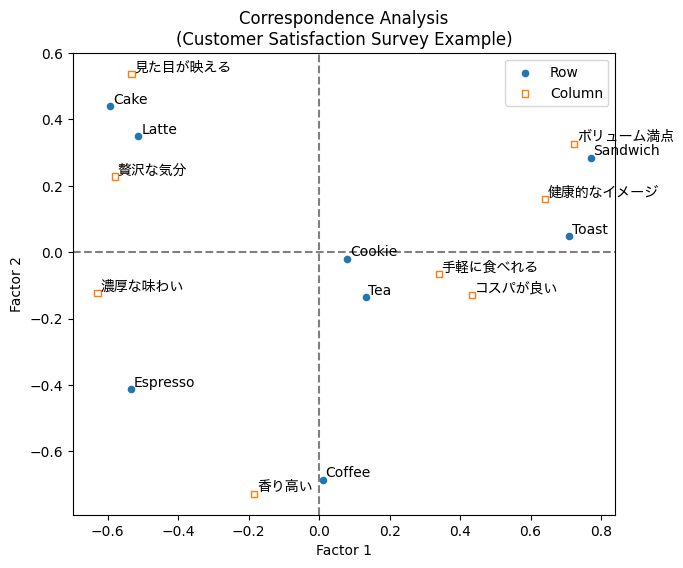

In [34]:
plt.figure(figsize=(7, 6))

# plt.rcParams['font.family'] = ['sans-serif', 'Meiryo']  # windows
plt.rcParams['font.family'] = ['sans-serif', 'Hiragino Sans']  # mac

# plot by row
plt.scatter(result_by_row[0], result_by_row[1], color='tab:blue', s=20, marker="o", label="Row")
for k, v in result_by_row.iterrows():
    plt.annotate(k, v, xytext=(2, 2), textcoords="offset points")

# plot by column
plt.scatter(result_by_column[0], result_by_column[1], color='tab:orange', s=20, marker='s', facecolors="none", label="Column")
for k, v in result_by_column.iterrows():
    plt.annotate(k, v, xytext=(2, 2), textcoords="offset points")

plt.axhline(0, color='gray', linestyle='dashed')
plt.axvline(0, color='gray', linestyle='dashed')
plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
plt.title("Correspondence Analysis\n(Customer Satisfaction Survey Example)")
plt.legend(loc='best')
# plt.gca().set_aspect("equal")
plt.show()

結果の解釈例  
- 左上のCakeとLatteは似たイメージでお客様から捉えられている
- CakeとLatteはともに「映える」「贅沢」といったリッチなイメージが強そう
- これらとは対極の右側にはSandwich, Toastが「手軽に食べれる」日常的なMenuとの評価
- 横軸（第1軸）はハレと日常を表すような背後要因が考えられる
- 下方のCoffeeはハレと日常の中間的ポジションながらも、Espressoともども「香り高い」イメージ
- 縦軸（第2軸）は寄与率が1軸ほど大きくなく、背後要因はやや読み解きにくい（今回使用したイメージワードでは不足だった可能性も考えられる）
- 中心付近にプロットされた「Cookie」「Tea」は他のMenuほどには強い特徴がみられなかったと解釈できる

# 2. メニュー × 性年代区分

In [35]:
# サンプルのdataframeを生成する

# メニュー（行）
menus = ['Coffee', 'Tea', 'Latte', 'Espresso', 'Cake', 'Sandwich', 'Cookie', 'Toast']

# 性年代10歳区分（列）
columns = [
    'M10s', 'M20s', 'M30s', 'M40s', 'M50s', 'M60s',
    'F10s', 'F20s', 'F30s', 'F40s', 'F50s', 'F60s'
]

# 各メニューの今後（継続）注文意向人数（n=1000くらいの規模感を想定）
# 世代や性別で好みが分かれるように数値を調整
data_demographic = [
    [20, 50, 70, 85, 90, 95, 15, 45, 65, 80, 85, 90], # Coffee: 男性・高年齢層に強い
    [10, 20, 30, 45, 55, 60, 25, 40, 55, 70, 75, 85], # Tea: 女性・高年齢層に強い
    [45, 80, 75, 50, 30, 20, 90, 95, 85, 60, 40, 25], # Latte: 若年層（特に女性）に圧倒的
    [ 5, 25, 55, 65, 45, 30,  2, 15, 35, 40, 30, 20], # Espresso: 30-40代男性、通好み
    [60, 75, 50, 40, 30, 25, 95, 90, 80, 60, 45, 40], # Cake: 若年層女性の鉄板
    [30, 55, 80, 85, 70, 60, 25, 50, 75, 80, 65, 55], # Sandwich: 30-40代のランチ需要
    [50, 65, 45, 35, 30, 30, 70, 80, 60, 45, 40, 35], # Cookie: 若年層全般
    [40, 60, 70, 75, 65, 60, 35, 55, 70, 75, 60, 55], # Toast: 30-40代・男女バランス型
]

df = pd.DataFrame(data_demographic, index=menus, columns=columns)

In [36]:
print(df.head())
# print(df.tail())
# print(df.info())

          M10s  M20s  M30s  M40s  M50s  M60s  F10s  F20s  F30s  F40s  F50s  \
Coffee      20    50    70    85    90    95    15    45    65    80    85   
Tea         10    20    30    45    55    60    25    40    55    70    75   
Latte       45    80    75    50    30    20    90    95    85    60    40   
Espresso     5    25    55    65    45    30     2    15    35    40    30   
Cake        60    75    50    40    30    25    95    90    80    60    45   

          F60s  
Coffee      90  
Tea         85  
Latte       25  
Espresso    20  
Cake        40  


In [37]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, Coffee to Toast
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   M10s    8 non-null      int64
 1   M20s    8 non-null      int64
 2   M30s    8 non-null      int64
 3   M40s    8 non-null      int64
 4   M50s    8 non-null      int64
 5   M60s    8 non-null      int64
 6   F10s    8 non-null      int64
 7   F20s    8 non-null      int64
 8   F30s    8 non-null      int64
 9   F40s    8 non-null      int64
 10  F50s    8 non-null      int64
 11  F60s    8 non-null      int64
dtypes: int64(12)
memory usage: 832.0+ bytes
None


In [38]:
# MCAの実行
ncol = df.shape[1]
mca_ben = mca.MCA(df, ncols=ncol, benzecri=False, TOL=1e-8)

In [39]:
# 行スコア（=座標）
result_by_row = pd.DataFrame(mca_ben.fs_r(N=2))
result_by_row.index = list(df.index)
print ("Score by row:")
print(result_by_row.round(3))

Score by row:
              0      1
Coffee    0.360  0.057
Tea       0.316  0.293
Latte    -0.409 -0.083
Espresso  0.369 -0.344
Cake     -0.423  0.065
Sandwich  0.171 -0.097
Cookie   -0.359  0.056
Toast     0.085 -0.048


In [40]:
# 列スコア（=座標）
result_by_column = pd.DataFrame(mca_ben.fs_c(N=2))
result_by_column.index = list(df.columns)
print ("Score by column:")
print(result_by_column.round(3))

Score by column:
          0      1
M10s -0.482  0.012
M20s -0.282 -0.098
M30s  0.043 -0.252
M40s  0.253 -0.222
M50s  0.355 -0.050
M60s  0.403  0.099
F10s -0.692  0.114
F20s -0.377  0.058
F30s -0.103 -0.018
F40s  0.118  0.018
F50s  0.221  0.140
F60s  0.310  0.294


In [41]:
# 固有値と寄与率

# MCAでは「行と列のどちらか少ない方の数-1」 が固有値（eigenvalue）の最大数になるためそれを算出
num_of_eigenvalue = min(len(df.index), len(df.columns)) - 1

data = {
    'Factor': range(1, len(mca_ben.L) + 1),
    'value': pd.Series(mca_ben.L),
    'ratio': mca_ben.expl_var(greenacre=False, N=num_of_eigenvalue)
}
columns = ['Factor', 'value', 'ratio']
table2 = pd.DataFrame(data=data, columns=columns).fillna(0)

# ratioの累計（cumulative_ratio）列を追加
table2['cum_ratio'] = table2['ratio'].cumsum()

print("Principal & Inertia(固有値 寄与率):")
print(table2.round(3).to_string(index=False))

Principal & Inertia(固有値 寄与率):
 Factor  value  ratio  cum_ratio
      1  0.107  0.801      0.801
      2  0.022  0.164      0.966
      3  0.003  0.023      0.989
      4  0.001  0.007      0.996
      5  0.000  0.003      0.999
      6  0.000  0.001      1.000
      7  0.000  0.000      1.000


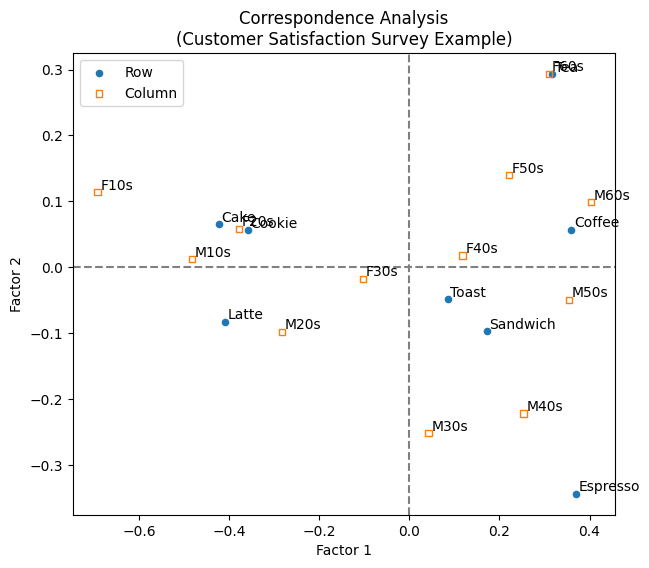

In [42]:
plt.figure(figsize=(7, 6))

# plt.rcParams['font.family'] = ['sans-serif', 'Meiryo']  # windows
plt.rcParams['font.family'] = ['sans-serif', 'Hiragino Sans']  # mac

# plot by row
plt.scatter(result_by_row[0], result_by_row[1], color='tab:blue', s=20, marker="o", label="Row")
for k, v in result_by_row.iterrows():
    plt.annotate(k, v, xytext=(2, 2), textcoords="offset points")

# plot by column
plt.scatter(result_by_column[0], result_by_column[1], color='tab:orange', s=20, marker='s', facecolors="none", label="Column")
for k, v in result_by_column.iterrows():
    plt.annotate(k, v, xytext=(2, 2), textcoords="offset points")

plt.axhline(0, color='gray', linestyle='dashed')
plt.axvline(0, color='gray', linestyle='dashed')
plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
plt.title("Correspondence Analysis\n(Customer Satisfaction Survey Example)")
plt.legend(loc='best')
# plt.gca().set_aspect("equal")
plt.show()

# 3. 回答者 × 5段階評価

In [43]:
# サンプルのdataframeを生成する

# 再現性のためシード固定
np.random.seed(42)

# カフェ利用の満足度に関連する10のイメージワード
columns = [
    "コーヒーの味", "店内の雰囲気", "スタッフの対応", "アクセスの良さ", 
    "価格の納得感", "メニューの豊富さ", "居心地の良さ", "清潔感", 
    "提供スピード", "リピート意向"
]

# 回答者10人分のダミーデータ作成
# 各ワードに対して 1(不満) ～ 5(満足) のランダムな評価を割り当て
n_users = 10
data = np.random.randint(1, 6, size=(n_users, len(columns)))

# DataFrame作成
df = pd.DataFrame(data, index=[f"cid_{i+1}" for i in range(n_users)], columns=columns)

In [44]:
print(df.head())
# print(df.tail())
# print(df.info())

       コーヒーの味  店内の雰囲気  スタッフの対応  アクセスの良さ  価格の納得感  メニューの豊富さ  居心地の良さ  清潔感  \
cid_1       4       5        3        5       5         2       3    3   
cid_2       4       3        5        2       4         2       4    5   
cid_3       2       5        4        1       1         3       3    2   
cid_4       3       4        4        1       3         5       3    5   
cid_5       4       1        4        2       2         1       2    5   

       提供スピード  リピート意向  
cid_1       3       5  
cid_2       1       4  
cid_3       4       4  
cid_4       1       2  
cid_5       2       4  


In [45]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, cid_1 to cid_10
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   コーヒーの味    10 non-null     int64
 1   店内の雰囲気    10 non-null     int64
 2   スタッフの対応   10 non-null     int64
 3   アクセスの良さ   10 non-null     int64
 4   価格の納得感    10 non-null     int64
 5   メニューの豊富さ  10 non-null     int64
 6   居心地の良さ    10 non-null     int64
 7   清潔感       10 non-null     int64
 8   提供スピード    10 non-null     int64
 9   リピート意向    10 non-null     int64
dtypes: int64(10)
memory usage: 880.0+ bytes
None


In [46]:
# MCAの実行
ncol = df.shape[1]
mca_ben = mca.MCA(df, ncols=ncol, benzecri=False, TOL=1e-8)

In [47]:
# 行スコア（=座標）
result_by_row = pd.DataFrame(mca_ben.fs_r(N=2))
result_by_row.index = list(df.index)
print ("Score by row:")
print(result_by_row.round(3))

Score by row:
            0      1
cid_1  -0.062  0.114
cid_2   0.128 -0.173
cid_3   0.150  0.144
cid_4   0.376 -0.228
cid_5  -0.034 -0.132
cid_6  -0.266  0.022
cid_7   0.108  0.154
cid_8   0.223  0.320
cid_9  -0.561  0.095
cid_10 -0.161 -0.442


In [48]:
# 列スコア（=座標）
result_by_column = pd.DataFrame(mca_ben.fs_c(N=2))
result_by_column.index = list(df.columns)
print ("Score by column:")
print(result_by_column.round(3))

Score by column:
              0      1
コーヒーの味   -0.294 -0.195
店内の雰囲気    0.249  0.245
スタッフの対応  -0.026  0.025
アクセスの良さ  -0.507  0.014
価格の納得感    0.181  0.125
メニューの豊富さ  0.332 -0.183
居心地の良さ   -0.022 -0.389
清潔感       0.278 -0.185
提供スピード   -0.201  0.287
リピート意向    0.044  0.183


In [49]:
# 固有値と寄与率

# MCAでは「行と列のどちらか少ない方の数-1」 が固有値（eigenvalue）の最大数になるためそれを算出
num_of_eigenvalue = min(len(df.index), len(df.columns)) - 1

data = {
    'Factor': range(1, len(mca_ben.L) + 1),
    'value': pd.Series(mca_ben.L),
    'ratio': mca_ben.expl_var(greenacre=False, N=num_of_eigenvalue)
}
columns = ['Factor', 'value', 'ratio']
table2 = pd.DataFrame(data=data, columns=columns).fillna(0)

# ratioの累計（cumulative_ratio）列を追加
table2['cum_ratio'] = table2['ratio'].cumsum()

print("Principal & Inertia(固有値 寄与率):")
print(table2.round(3).to_string(index=False))

Principal & Inertia(固有値 寄与率):
 Factor  value  ratio  cum_ratio
      1  0.063  0.347      0.347
      2  0.043  0.240      0.587
      3  0.035  0.195      0.782
      4  0.021  0.118      0.900
      5  0.008  0.045      0.945
      6  0.005  0.030      0.975
      7  0.003  0.015      0.991
      8  0.002  0.009      1.000
      9  0.000  0.000      1.000


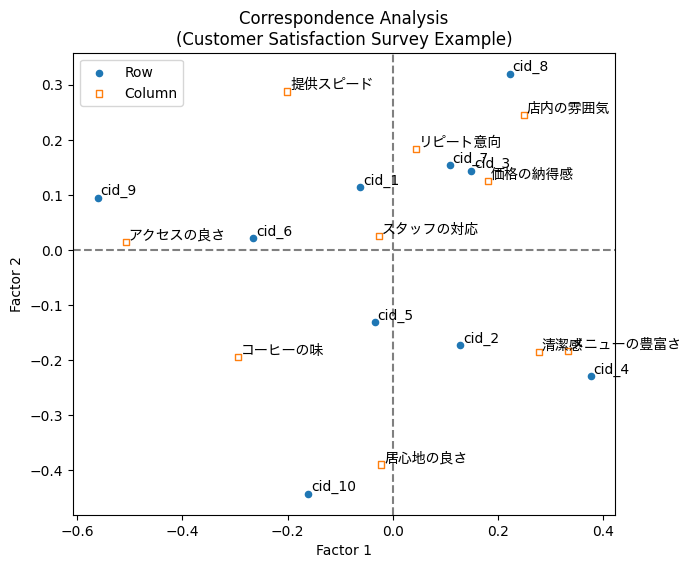

In [50]:
plt.figure(figsize=(7, 6))

# plt.rcParams['font.family'] = ['sans-serif', 'Meiryo']  # windows
plt.rcParams['font.family'] = ['sans-serif', 'Hiragino Sans']  # mac

# plot by row
plt.scatter(result_by_row[0], result_by_row[1], color='tab:blue', s=20, marker="o", label="Row")
for k, v in result_by_row.iterrows():
    plt.annotate(k, v, xytext=(2, 2), textcoords="offset points")

# plot by column
plt.scatter(result_by_column[0], result_by_column[1], color='tab:orange', s=20, marker='s', facecolors="none", label="Column")
for k, v in result_by_column.iterrows():
    plt.annotate(k, v, xytext=(2, 2), textcoords="offset points")

plt.axhline(0, color='gray', linestyle='dashed')
plt.axvline(0, color='gray', linestyle='dashed')
plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
plt.title("Correspondence Analysis\n(Customer Satisfaction Survey Example)")
plt.legend(loc='best')
# plt.gca().set_aspect("equal")
plt.show()